# Noise Sample Analysis & Preprocessing

Analyzes the 360 real-world noise samples collected from an Arduino Nano 33 BLE Sense Rev2
mounted on a real vehicle. These samples will be used for realistic noise injection during
data augmentation to bridge the domain gap between controlled training recordings and
real-world deployment conditions.

**Sections:**
1. Inventory & distribution of collected samples
2. Audio quality validation (clipping, silence, anomalies)
3. Spectral analysis per noise category
4. RMS energy profiling & normalization
5. Category grouping for augmentation strategy
6. Export preprocessed noise bank

In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

plt.rcParams.update({'figure.dpi': 100, 'font.size': 10})

# Paths — handle running from notebooks/ dir or project root
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
NOISE_DIR = PROJECT_ROOT / 'data' / 'noise_samples' / 'noise_samples'
LOG_FILE = NOISE_DIR / 'collection_log.csv'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'noise_bank'

print(f'Noise directory: {NOISE_DIR}')
print(f'Output directory: {OUTPUT_DIR}')

Noise directory: /home/robert/BDA602/Car_Sounds/data/noise_samples/noise_samples
Output directory: /home/robert/BDA602/Car_Sounds/data/noise_bank


## 1. Inventory & Distribution

In [2]:
# Load collection log
log_df = pd.read_csv(LOG_FILE)
log_df['timestamp'] = pd.to_datetime(log_df['timestamp'])

# Fix Windows backslashes in filename column
log_df['filename'] = log_df['filename'].str.replace('\\', '/', regex=False)

print(f'Total samples: {len(log_df)}')
print(f'Categories: {log_df["label"].nunique()}')
print(f'Collection period: {log_df["timestamp"].min()} → {log_df["timestamp"].max()}')
print(f'\nSamples per category:')
counts = log_df['label'].value_counts().sort_index()
for label, count in counts.items():
    print(f'  {label:50s}  {count:3d}')

Total samples: 360
Categories: 23
Collection period: 2026-03-22 14:25:44.925112 → 2026-03-22 15:27:47.417032

Samples per category:
  ambient_under_hood                                   23
  busy_highway_ambient                                 20
  busy_street_ambient                                  10
  cold_engine_just_started_under_hood                  20
  engine_fan_on_under_hood                             20
  fan_speed_1_idle_under_hood                          10
  fan_speed_max_idle_under_hood                        10
  fan_speed_medium_idle_under_hood                     10
  interior_cabin_city_streets_windows_up               10
  interior_cabin_city_windows_down                     10
  interior_cabin_highway_speeds_windows_down           20
  interior_cabin_highway_speeds_windows_up             20
  low_speed_residential_under_hood                     20
  moderate_speed_city_under_hood                       20
  parking_lot_windows_down_ambient                     2

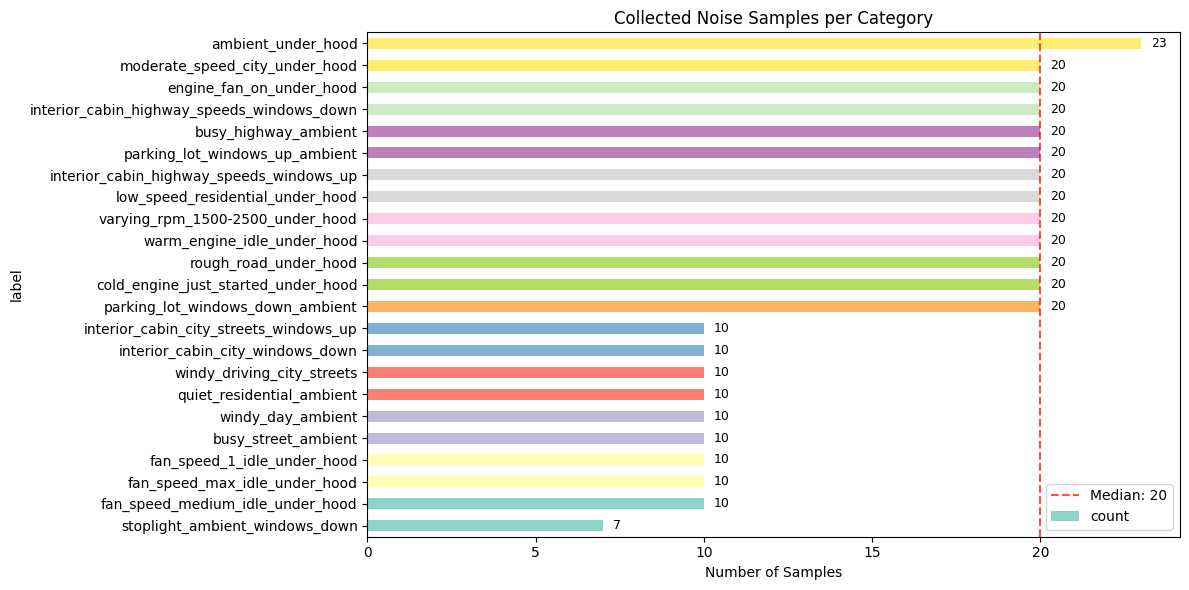

In [3]:
# Visualize distribution
fig, ax = plt.subplots(figsize=(12, 6))
counts_sorted = log_df['label'].value_counts().sort_values(ascending=True)
colors = plt.cm.Set3(np.linspace(0, 1, len(counts_sorted)))
counts_sorted.plot.barh(ax=ax, color=colors)
ax.set_xlabel('Number of Samples')
ax.set_title('Collected Noise Samples per Category')
ax.axvline(x=counts_sorted.median(), color='red', linestyle='--', alpha=0.7, label=f'Median: {counts_sorted.median():.0f}')
ax.legend()
for i, (v, label) in enumerate(zip(counts_sorted.values, counts_sorted.index)):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 2. Audio Quality Validation

Load all WAV files and check for:
- Correct sample rate (16 kHz) and duration (1.5 s / 24000 samples)
- Clipping (samples at ±1.0)
- Near-silence (RMS < threshold)
- Anomalously loud samples

In [4]:
# Load all noise samples
noise_data = {}  # label -> list of (filename, waveform)
quality_issues = []

for _, row in log_df.iterrows():
    label = row['label']
    # Build actual file path from label subdirectory + filename
    fname = Path(row['filename']).name
    fpath = NOISE_DIR / label / fname
    
    if not fpath.exists():
        quality_issues.append((fname, label, 'FILE_NOT_FOUND'))
        continue
    
    y, sr = librosa.load(fpath, sr=None)
    
    # Validate
    if sr != 16000:
        quality_issues.append((fname, label, f'WRONG_SR: {sr}'))
    if len(y) != 24000:
        quality_issues.append((fname, label, f'WRONG_LEN: {len(y)}'))
    
    rms = np.sqrt(np.mean(y**2))
    peak = np.max(np.abs(y))
    clip_count = np.sum(np.abs(y) >= 0.999)
    
    if clip_count > 10:
        quality_issues.append((fname, label, f'CLIPPING: {clip_count} samples'))
    if rms < 0.001:
        quality_issues.append((fname, label, f'NEAR_SILENCE: rms={rms:.6f}'))
    
    if label not in noise_data:
        noise_data[label] = []
    noise_data[label].append({'fname': fname, 'y': y, 'rms': rms, 'peak': peak, 'clip_count': clip_count})

print(f'Loaded: {sum(len(v) for v in noise_data.values())} samples across {len(noise_data)} categories')
if quality_issues:
    print(f'\nQuality issues found ({len(quality_issues)}):')
    for fname, label, issue in quality_issues:
        print(f'  [{label}] {fname}: {issue}')
else:
    print('No quality issues found.')

/home/robert/BDA602/Car_Sounds/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded: 360 samples across 23 categories
No quality issues found.


In [5]:
# RMS and peak distribution per category
stats_rows = []
for label in sorted(noise_data.keys()):
    samples = noise_data[label]
    rms_vals = [s['rms'] for s in samples]
    peak_vals = [s['peak'] for s in samples]
    clip_vals = [s['clip_count'] for s in samples]
    stats_rows.append({
        'Category': label,
        'N': len(samples),
        'RMS Mean': np.mean(rms_vals),
        'RMS Std': np.std(rms_vals),
        'RMS Min': np.min(rms_vals),
        'RMS Max': np.max(rms_vals),
        'Peak Mean': np.mean(peak_vals),
        'Peak Max': np.max(peak_vals),
        'Clipped Samples': sum(c > 0 for c in clip_vals),
    })

stats_df = pd.DataFrame(stats_rows)
print(stats_df.to_string(index=False, float_format='%.4f'))

                                  Category  N  RMS Mean  RMS Std  RMS Min  RMS Max  Peak Mean  Peak Max  Clipped Samples
                        ambient_under_hood 23    0.0163   0.0105   0.0124   0.0504     0.0904    0.6068                0
                      busy_highway_ambient 20    0.0190   0.0044   0.0124   0.0313     0.1305    0.2567                0
                       busy_street_ambient 10    0.0095   0.0004   0.0091   0.0103     0.0425    0.0482                0
       cold_engine_just_started_under_hood 20    0.0310   0.0092   0.0205   0.0568     0.1245    0.2049                0
                  engine_fan_on_under_hood 20    0.0389   0.0061   0.0291   0.0503     0.1486    0.2137                0
               fan_speed_1_idle_under_hood 10    0.0152   0.0011   0.0134   0.0163     0.0614    0.0724                0
             fan_speed_max_idle_under_hood 10    0.0149   0.0014   0.0132   0.0174     0.0639    0.0764                0
          fan_speed_medium_idle_

/tmp/ipykernel_1169665/3045816299.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(rms_per_cat, labels=labels_sorted, vert=True, patch_artist=True)


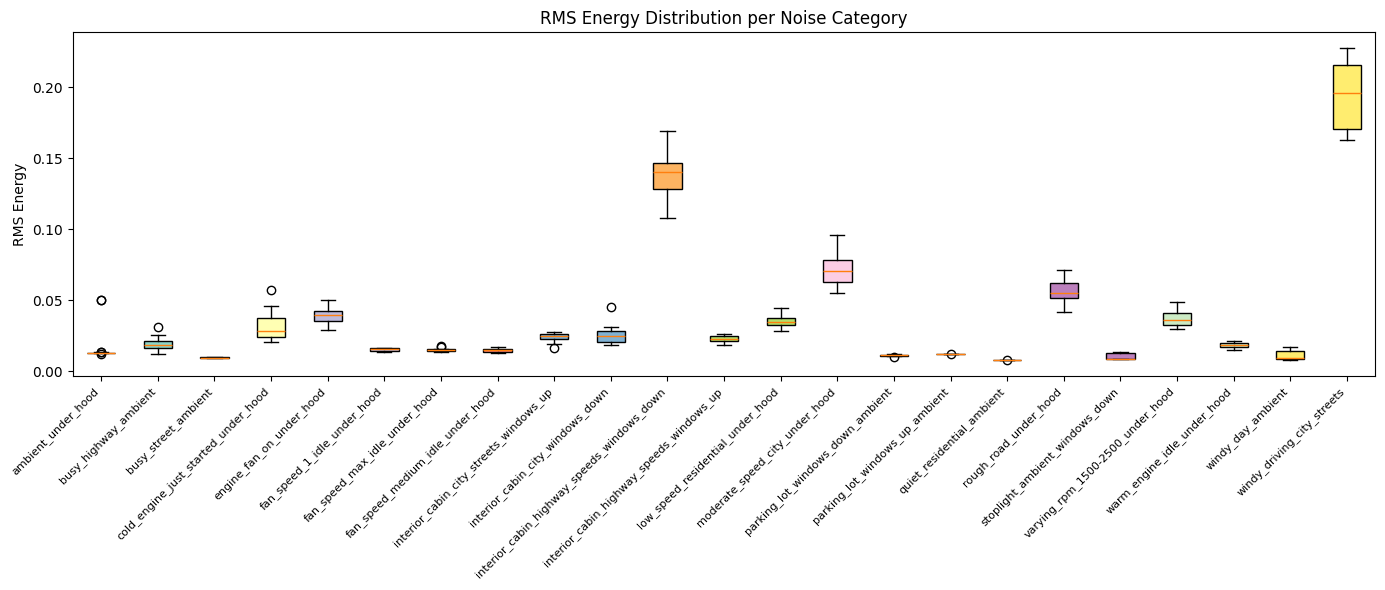

In [6]:
# Box plot of RMS per category
fig, ax = plt.subplots(figsize=(14, 6))
labels_sorted = sorted(noise_data.keys())
rms_per_cat = [np.array([s['rms'] for s in noise_data[l]]) for l in labels_sorted]
bp = ax.boxplot(rms_per_cat, labels=labels_sorted, vert=True, patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.Set3(np.linspace(0, 1, len(labels_sorted)))):
    patch.set_facecolor(color)
ax.set_xticklabels(labels_sorted, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('RMS Energy')
ax.set_title('RMS Energy Distribution per Noise Category')
plt.tight_layout()
plt.show()

## 3. Spectral Analysis

Compute average mel-spectrograms per category to understand the frequency content
of each noise type. This helps us understand which noise types will affect which
frequency bands of the car diagnostic sounds.

In [7]:
# Compute average mel-spectrogram per category
avg_specs = {}
for label in sorted(noise_data.keys()):
    specs = []
    for s in noise_data[label]:
        S = librosa.feature.melspectrogram(
            y=s['y'], sr=16000, n_fft=512, hop_length=256,
            n_mels=40, fmin=20, fmax=8000
        )
        S_dB = librosa.power_to_db(S, ref=np.max)
        specs.append(S_dB)
    avg_specs[label] = np.mean(specs, axis=0)

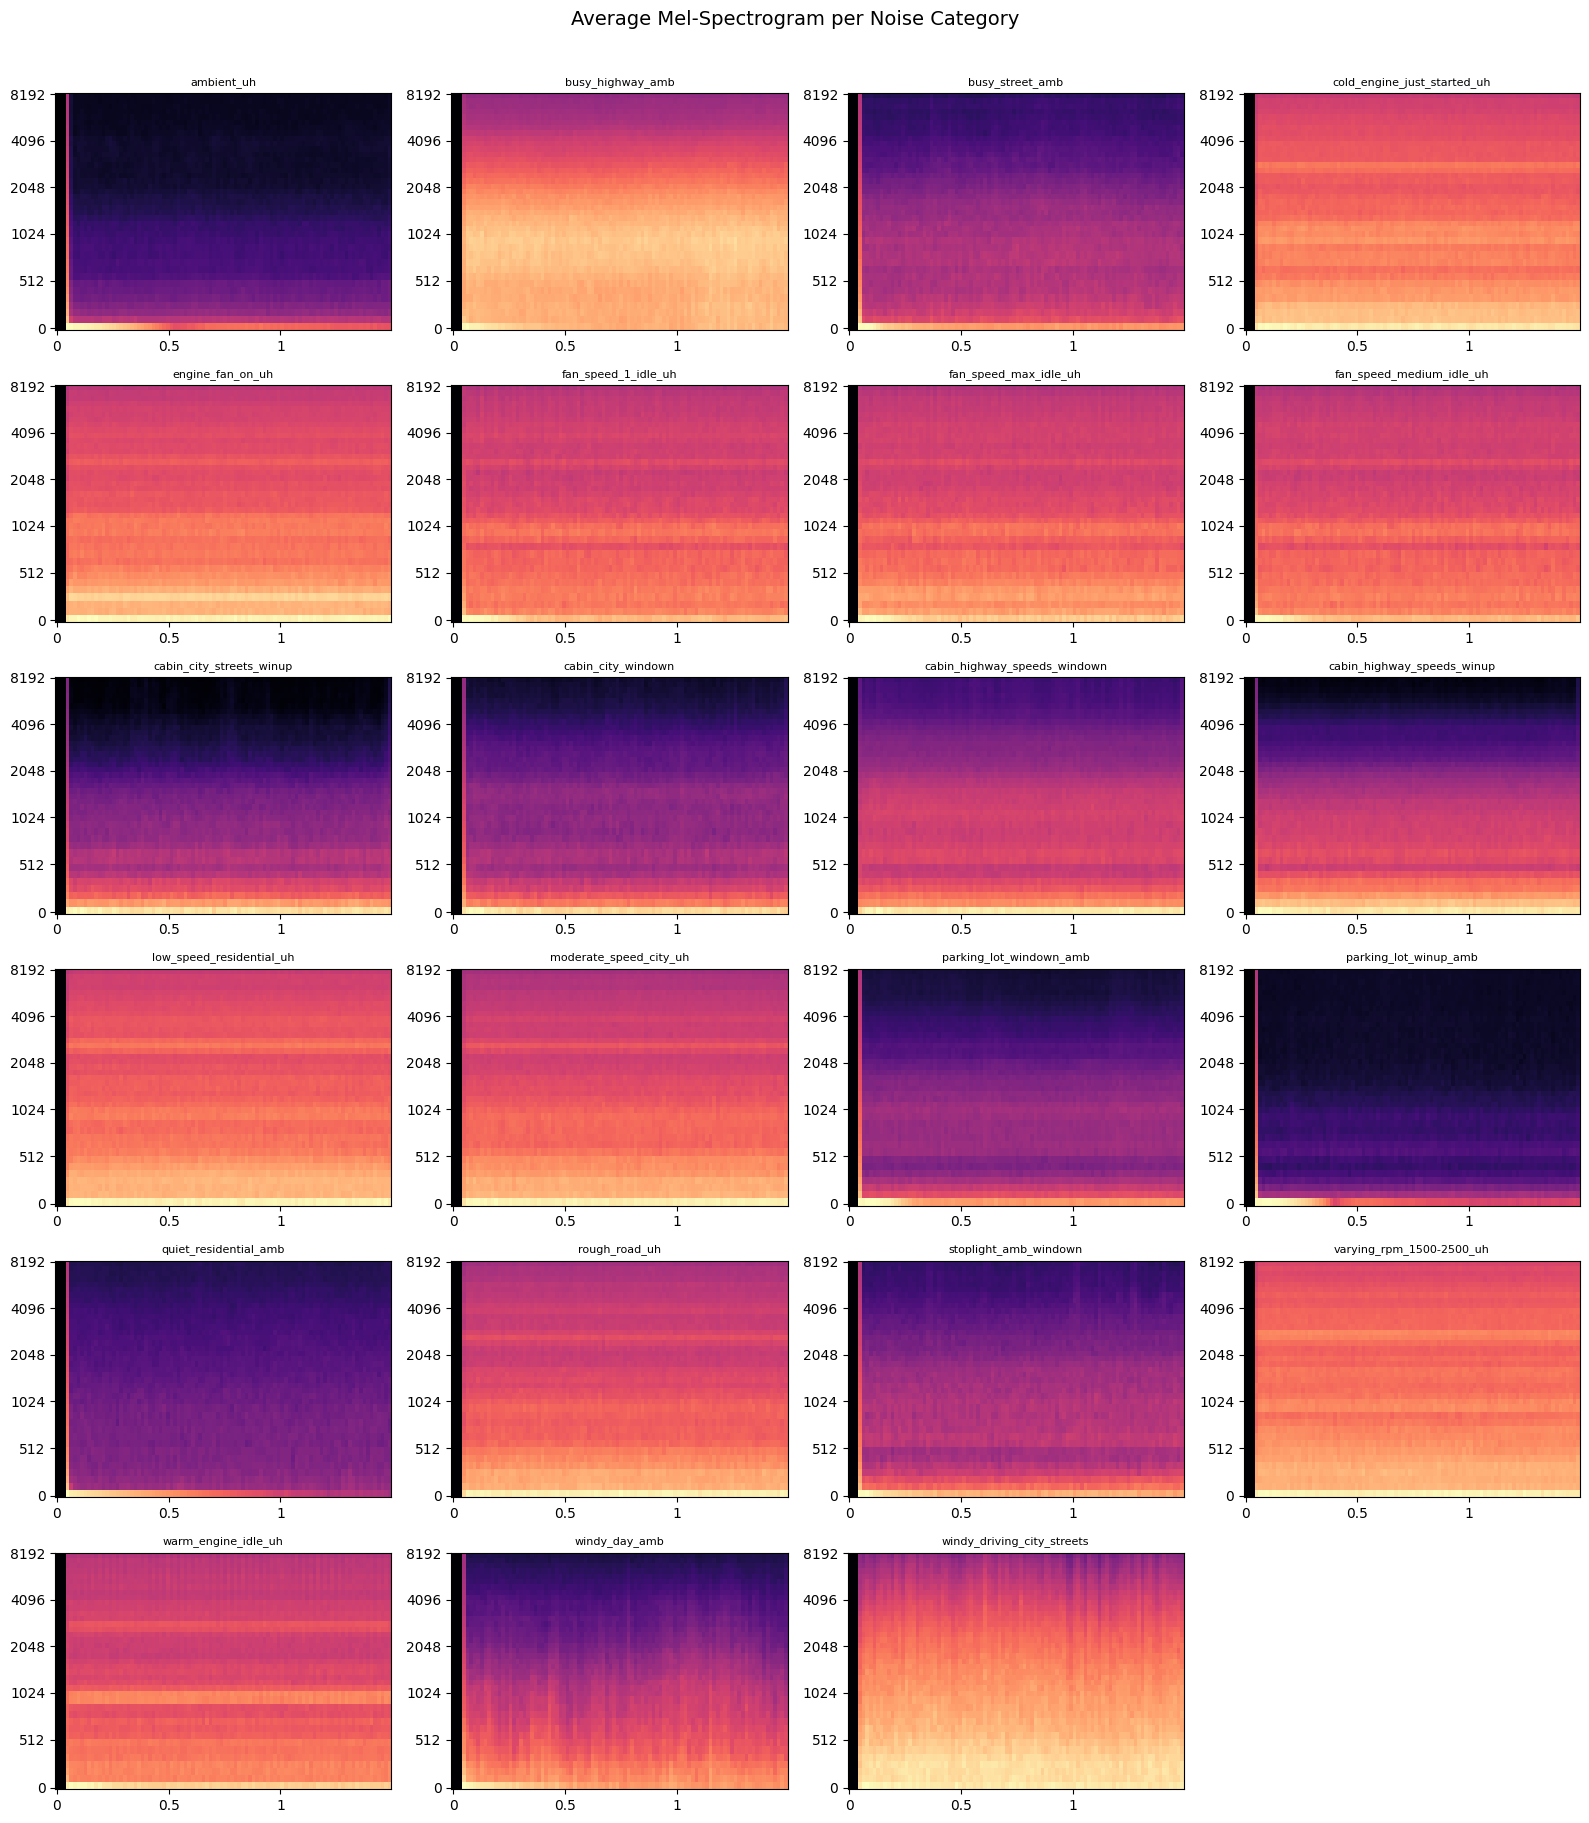

In [8]:
# Plot average mel-spectrograms in a grid
labels_sorted = sorted(avg_specs.keys())
n_cats = len(labels_sorted)
ncols = 4
nrows = (n_cats + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3 * nrows))
axes = axes.flatten()

for i, label in enumerate(labels_sorted):
    ax = axes[i]
    img = librosa.display.specshow(
        avg_specs[label], sr=16000, hop_length=256,
        x_axis='time', y_axis='mel', fmin=20, fmax=8000,
        ax=ax, cmap='magma'
    )
    short_name = label.replace('_under_hood', '_uh').replace('_ambient', '_amb')
    short_name = short_name.replace('interior_cabin_', 'cabin_').replace('windows_', 'win')
    ax.set_title(short_name, fontsize=8)
    ax.set_xlabel('')
    ax.set_ylabel('')

# Hide unused subplots
for i in range(n_cats, len(axes)):
    axes[i].set_visible(False)

fig.suptitle('Average Mel-Spectrogram per Noise Category', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

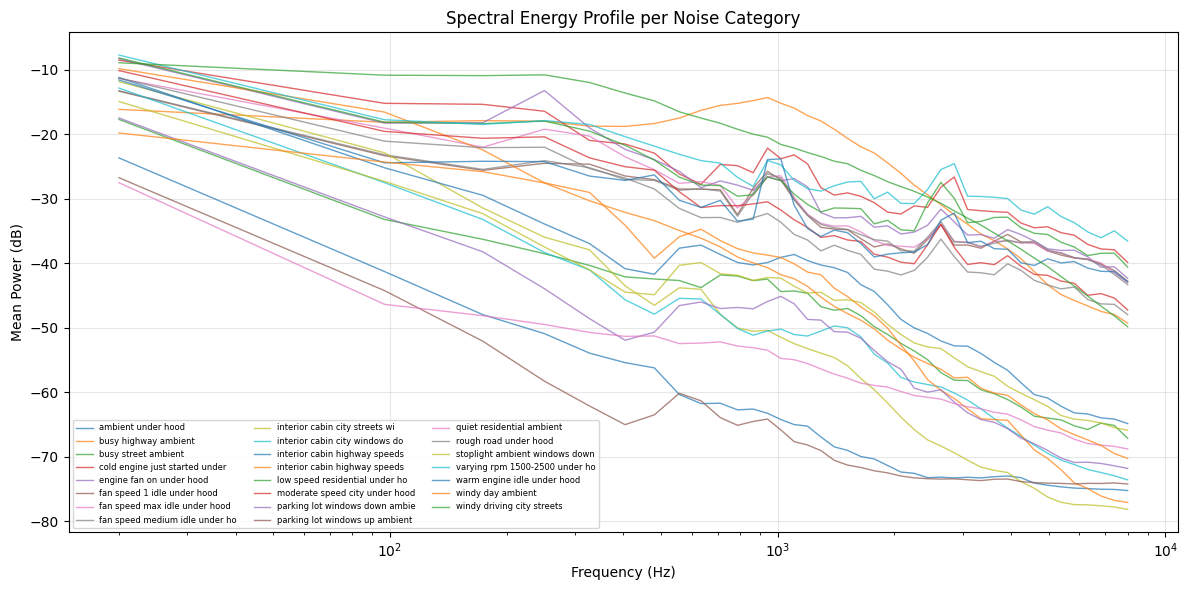

In [9]:
# Average spectral energy profile per category (mean across time)
fig, ax = plt.subplots(figsize=(12, 6))
mel_freqs = librosa.mel_frequencies(n_mels=40, fmin=20, fmax=8000)

for label in labels_sorted:
    profile = np.mean(avg_specs[label], axis=1)  # mean across time -> (40,)
    ax.plot(mel_freqs, profile, alpha=0.7, linewidth=1, label=label.replace('_', ' ')[:30])

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Mean Power (dB)')
ax.set_title('Spectral Energy Profile per Noise Category')
ax.set_xscale('log')
ax.legend(fontsize=6, ncol=3, loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Category Grouping for Augmentation

Group the 23 fine-grained labels into broader noise categories that align with
deployment scenarios. This grouping determines which noise types are mixed with
which training classes during augmentation.

In [10]:
# Define noise groups based on deployment relevance
NOISE_GROUPS = {
    'engine_mechanical': [
        'ambient_under_hood',
        'cold_engine_just_started_under_hood',
        'warm_engine_idle_under_hood',
        'varying_rpm_1500-2500_under_hood',
        'engine_fan_on_under_hood',
    ],
    'hvac': [
        'fan_speed_1_idle_under_hood',
        'fan_speed_medium_idle_under_hood',
        'fan_speed_max_idle_under_hood',
    ],
    'road_driving': [
        'low_speed_residential_under_hood',
        'moderate_speed_city_under_hood',
        'rough_road_under_hood',
    ],
    'cabin_driving': [
        'interior_cabin_city_streets_windows_up',
        'interior_cabin_city_windows_down',
        'interior_cabin_highway_speeds_windows_up',
        'interior_cabin_highway_speeds_windows_down',
    ],
    'wind': [
        'windy_day_ambient',
        'windy_driving_city_streets',
    ],
    'ambient_stationary': [
        'parking_lot_windows_up_ambient',
        'parking_lot_windows_down_ambient',
        'quiet_residential_ambient',
        'stoplight_ambient_windows_down',
        'busy_street_ambient',
        'busy_highway_ambient',
    ],
}

# Verify all labels are assigned to a group
all_assigned = set()
for group, labels in NOISE_GROUPS.items():
    all_assigned.update(labels)
unassigned = set(noise_data.keys()) - all_assigned
if unassigned:
    print(f'WARNING: Unassigned labels: {unassigned}')
else:
    print('All labels assigned to groups.')

# Summary
print(f'\n{"Group":<25s} {"Labels":>6s} {"Samples":>7s}')
print('-' * 42)
for group, labels in NOISE_GROUPS.items():
    n_samples = sum(len(noise_data.get(l, [])) for l in labels)
    print(f'{group:<25s} {len(labels):>6d} {n_samples:>7d}')

All labels assigned to groups.

Group                     Labels Samples
------------------------------------------
engine_mechanical              5     103
hvac                           3      30
road_driving                   3      60
cabin_driving                  4      60
wind                           2      20
ambient_stationary             6      87


In [11]:
# Which noise groups are most relevant for each training class (operational state)?
# This mapping guides which noises to mix with which training samples.
NOISE_RELEVANCE = {
    # Braking classes: car is moving, mic near engine/wheels
    'braking': ['engine_mechanical', 'road_driving', 'cabin_driving', 'wind', 'hvac'],
    # Idle classes: car is stationary, engine running
    'idle':    ['engine_mechanical', 'hvac', 'ambient_stationary', 'wind'],
    # Startup classes: engine turning over, stationary
    'startup': ['ambient_stationary', 'wind', 'hvac'],
}

print('Noise group relevance by operational state:')
for state, groups in NOISE_RELEVANCE.items():
    total = sum(sum(len(noise_data.get(l, [])) for l in NOISE_GROUPS[g]) for g in groups)
    print(f'  {state:10s}: {total:3d} noise samples from groups: {", ".join(groups)}')

Noise group relevance by operational state:
  braking   : 273 noise samples from groups: engine_mechanical, road_driving, cabin_driving, wind, hvac
  idle      : 240 noise samples from groups: engine_mechanical, hvac, ambient_stationary, wind
  startup   : 137 noise samples from groups: ambient_stationary, wind, hvac


## 5. Compare Noise Energy to Training Data

To mix noise at realistic SNR levels, we need to understand the energy
relationship between our noise samples and the training audio.

In [12]:
# Load original training samples to compare RMS levels
import sys
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from preprocessing import preprocess_split

# Load training audio
train_audio, train_labels, train_paths = preprocess_split(
    str(PROJECT_ROOT / 'data' / 'splits' / 'train_manifest.csv'),
    str(PROJECT_ROOT)
)

train_rms = np.sqrt(np.mean(train_audio**2, axis=1))
noise_rms_all = np.array([s['rms'] for samples in noise_data.values() for s in samples])

print(f'Training audio RMS — mean: {train_rms.mean():.4f}, std: {train_rms.std():.4f}, '
      f'min: {train_rms.min():.4f}, max: {train_rms.max():.4f}')
print(f'Noise samples RMS — mean: {noise_rms_all.mean():.4f}, std: {noise_rms_all.std():.4f}, '
      f'min: {noise_rms_all.min():.4f}, max: {noise_rms_all.max():.4f}')

Preprocessing audio:   0%|          | 0/970 [00:00<?, ?it/s]

Preprocessing audio:   4%|▎         | 36/970 [00:00<00:02, 352.12it/s]

Preprocessing audio:   7%|▋         | 72/970 [00:00<00:02, 332.71it/s]

Preprocessing audio:  12%|█▏        | 118/970 [00:00<00:02, 386.70it/s]

Preprocessing audio:  17%|█▋        | 163/970 [00:00<00:01, 408.89it/s]

...

Preprocessing audio:  83%|████████▎ | 805/970 [00:01<00:00, 631.31it/s]

Preprocessing audio:  90%|█████████ | 875/970 [00:01<00:00, 649.18it/s]

Preprocessing audio:  97%|█████████▋| 945/970 [00:01<00:00, 661.97it/s]

Preprocessing audio: 100%|██████████| 970/970 [00:01<00:00, 548.69it/s]

Training audio RMS — mean: 0.2102, std: 0.0604, min: 0.0332, max: 0.4317
Noise samples RMS — mean: 0.0374, std: 0.0410, min: 0.0076, max: 0.2277


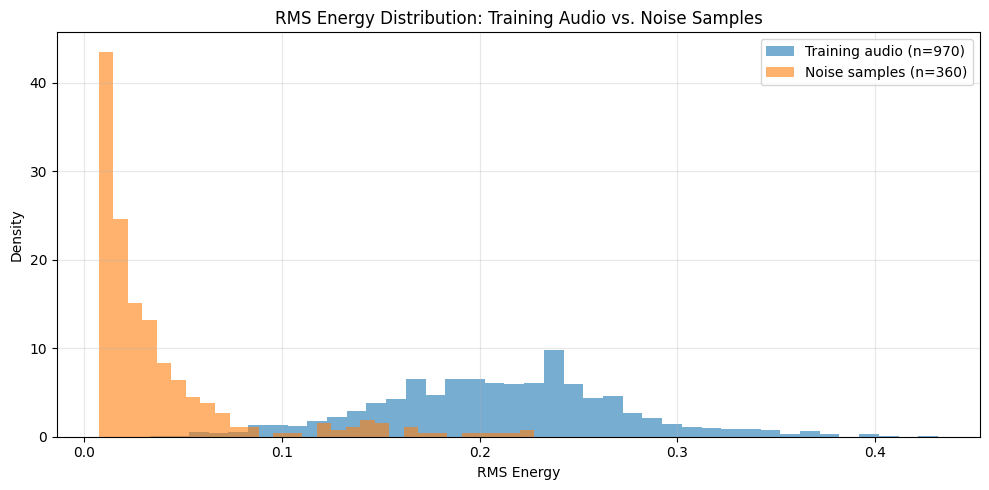


Natural SNR (if noise added without scaling): 11.9 dB
We will scale noise to target specific SNR levels (5, 10, 15, 20 dB) during augmentation.


In [13]:
# Histogram comparison
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train_rms, bins=40, alpha=0.6, label=f'Training audio (n={len(train_rms)})', density=True)
ax.hist(noise_rms_all, bins=30, alpha=0.6, label=f'Noise samples (n={len(noise_rms_all)})', density=True)
ax.set_xlabel('RMS Energy')
ax.set_ylabel('Density')
ax.set_title('RMS Energy Distribution: Training Audio vs. Noise Samples')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Effective SNR range if noise were added directly (no scaling)
mean_signal_power = np.mean(train_rms**2)
mean_noise_power = np.mean(noise_rms_all**2)
natural_snr = 10 * np.log10(mean_signal_power / mean_noise_power)
print(f'\nNatural SNR (if noise added without scaling): {natural_snr:.1f} dB')
print('We will scale noise to target specific SNR levels (5, 10, 15, 20 dB) during augmentation.')

## 6. Visualize Noise Mixing Example

Demonstrate what mixing a training sample with real-world noise looks like
at different SNR levels.

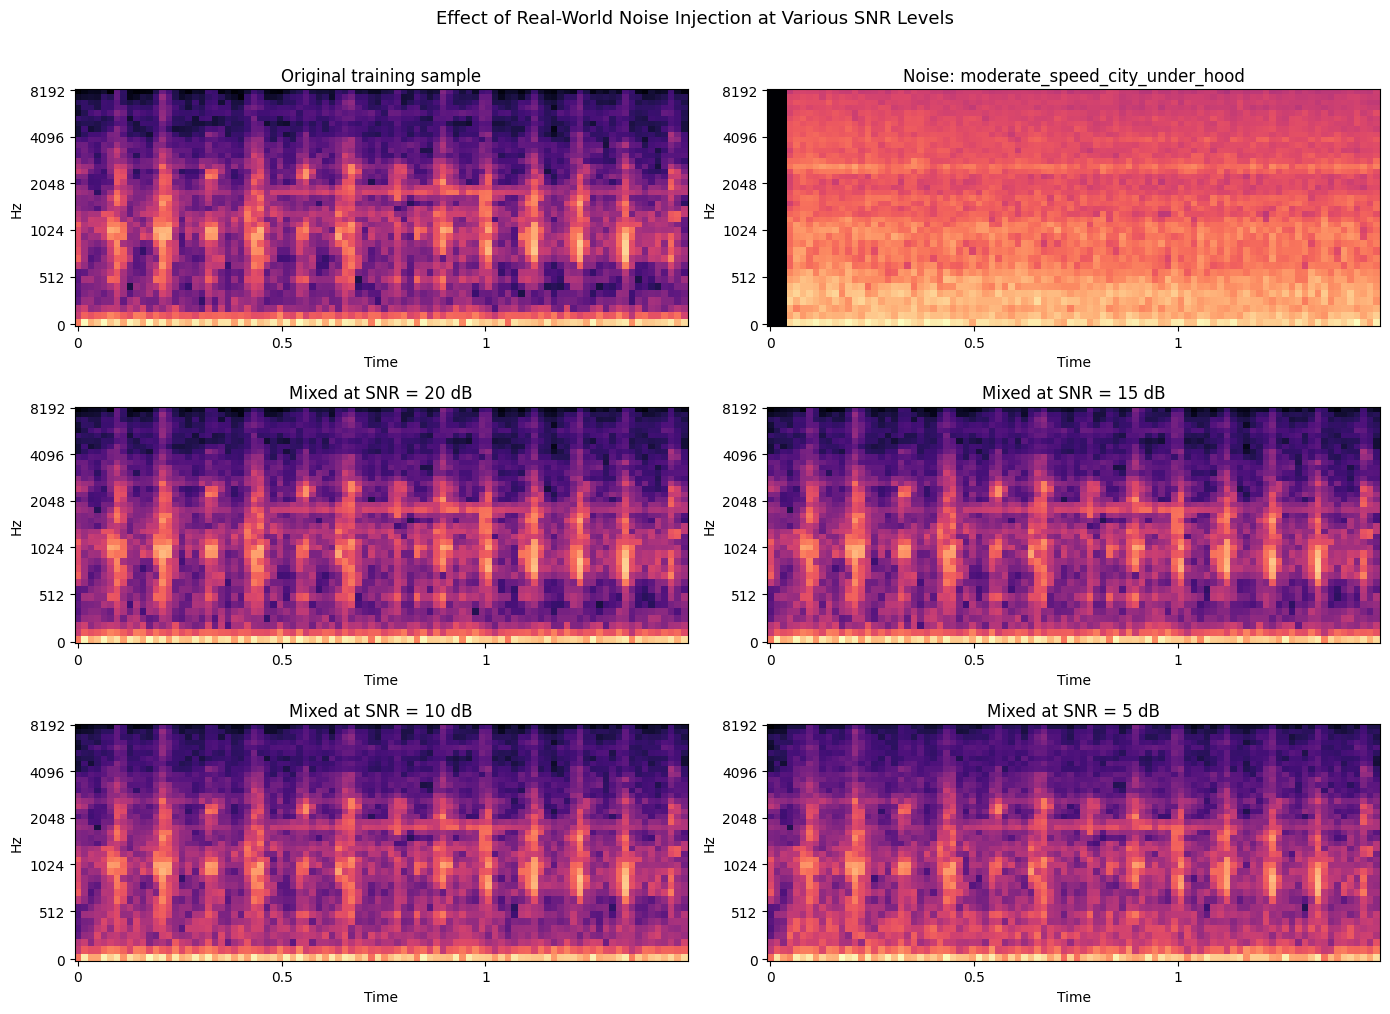

In [14]:
def mix_at_snr(signal, noise, snr_db):
    """Mix noise into signal at a target SNR."""
    signal_power = np.mean(signal**2)
    noise_power = np.mean(noise**2)
    if noise_power == 0:
        return signal.copy()
    target_noise_power = signal_power / (10 ** (snr_db / 10))
    scale = np.sqrt(target_noise_power / noise_power)
    return signal + scale * noise

# Pick a training sample and a noise sample
sample_idx = 50  # arbitrary
signal = train_audio[sample_idx]
noise_sample = noise_data['moderate_speed_city_under_hood'][0]['y']

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
snr_levels = [20, 15, 10, 5, 0]

# Original signal
S_orig = librosa.feature.melspectrogram(y=signal, sr=16000, n_fft=512, hop_length=256,
                                        n_mels=40, fmin=20, fmax=8000)
librosa.display.specshow(librosa.power_to_db(S_orig, ref=np.max), sr=16000, hop_length=256,
                         x_axis='time', y_axis='mel', fmin=20, fmax=8000, ax=axes[0, 0], cmap='magma')
axes[0, 0].set_title('Original training sample')

# Noise alone
S_noise = librosa.feature.melspectrogram(y=noise_sample, sr=16000, n_fft=512, hop_length=256,
                                         n_mels=40, fmin=20, fmax=8000)
librosa.display.specshow(librosa.power_to_db(S_noise, ref=np.max), sr=16000, hop_length=256,
                         x_axis='time', y_axis='mel', fmin=20, fmax=8000, ax=axes[0, 1], cmap='magma')
axes[0, 1].set_title('Noise: moderate_speed_city_under_hood')

# Mixed at various SNRs
for i, snr in enumerate(snr_levels[:4]):
    row = (i + 2) // 2
    col = (i + 2) % 2
    mixed = mix_at_snr(signal, noise_sample, snr)
    S_mixed = librosa.feature.melspectrogram(y=mixed, sr=16000, n_fft=512, hop_length=256,
                                             n_mels=40, fmin=20, fmax=8000)
    librosa.display.specshow(librosa.power_to_db(S_mixed, ref=np.max), sr=16000, hop_length=256,
                             x_axis='time', y_axis='mel', fmin=20, fmax=8000, ax=axes[row, col], cmap='magma')
    axes[row, col].set_title(f'Mixed at SNR = {snr} dB')

fig.suptitle('Effect of Real-World Noise Injection at Various SNR Levels', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Check for Duplicate / Near-Duplicate Samples

Since some samples were collected in rapid succession (every ~1.8s), consecutive
samples within the same label may be nearly identical. Flag pairs with very high
correlation so we can decide whether to keep or drop them.

In [15]:
# Check intra-category pairwise correlation
dup_report = []
for label in sorted(noise_data.keys()):
    samples = noise_data[label]
    if len(samples) < 2:
        continue
    waveforms = np.array([s['y'] for s in samples])
    # Normalize each waveform for correlation
    norms = np.linalg.norm(waveforms, axis=1, keepdims=True)
    norms[norms == 0] = 1
    waveforms_norm = waveforms / norms
    corr_matrix = waveforms_norm @ waveforms_norm.T
    # Get upper triangle (excluding diagonal)
    upper = corr_matrix[np.triu_indices(len(samples), k=1)]
    n_high_corr = np.sum(upper > 0.95)
    dup_report.append({
        'Category': label,
        'N': len(samples),
        'Mean Corr': np.mean(upper),
        'Max Corr': np.max(upper),
        'Pairs > 0.95': n_high_corr,
    })

dup_df = pd.DataFrame(dup_report)
print('Intra-category waveform correlation:')
print(dup_df.to_string(index=False, float_format='%.3f'))

total_high_corr = dup_df['Pairs > 0.95'].sum()
print(f'\nTotal near-duplicate pairs (corr > 0.95): {total_high_corr}')
if total_high_corr > 0:
    print('Consider dropping one sample from each near-duplicate pair.')
else:
    print('No near-duplicates found — all samples provide unique information.')

Intra-category waveform correlation:
                                  Category  N  Mean Corr  Max Corr  Pairs > 0.95
                        ambient_under_hood 23      0.838     1.000           211
                      busy_highway_ambient 20      0.282     0.444             0
                       busy_street_ambient 10      0.891     0.959             1
       cold_engine_just_started_under_hood 20      0.245     0.432             0
                  engine_fan_on_under_hood 20      0.152     0.377             0
               fan_speed_1_idle_under_hood 10      0.739     0.836             0
             fan_speed_max_idle_under_hood 10      0.644     0.808             0
          fan_speed_medium_idle_under_hood 10      0.743     0.916             0
    interior_cabin_city_streets_windows_up 10      0.304     0.520             0
          interior_cabin_city_windows_down 10      0.221     0.366             0
interior_cabin_highway_speeds_windows_down 20      0.125     0.411      

## 8. Export Preprocessed Noise Bank

Save all noise samples in a single `.npz` file organized by group,
with metadata for efficient loading during augmentation.

In [16]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Build arrays per group
group_arrays = {}
group_labels = {}
group_rms = {}

for group, labels in NOISE_GROUPS.items():
    waveforms = []
    source_labels = []
    rms_vals = []
    for label in labels:
        for s in noise_data.get(label, []):
            waveforms.append(s['y'])
            source_labels.append(label)
            rms_vals.append(s['rms'])
    group_arrays[group] = np.array(waveforms, dtype=np.float32)
    group_labels[group] = np.array(source_labels)
    group_rms[group] = np.array(rms_vals, dtype=np.float32)
    print(f'{group:25s}: {len(waveforms):3d} samples, shape {group_arrays[group].shape}')

# Save as single npz
save_dict = {}
for group in NOISE_GROUPS:
    save_dict[f'{group}_audio'] = group_arrays[group]
    save_dict[f'{group}_labels'] = group_labels[group]
    save_dict[f'{group}_rms'] = group_rms[group]
save_dict['group_names'] = np.array(list(NOISE_GROUPS.keys()))

output_path = OUTPUT_DIR / 'noise_bank.npz'
np.savez_compressed(output_path, **save_dict)
size_mb = output_path.stat().st_size / (1024 * 1024)
print(f'\nSaved: {output_path} ({size_mb:.1f} MB)')

engine_mechanical        : 103 samples, shape (103, 24000)
hvac                     :  30 samples, shape (30, 24000)
road_driving             :  60 samples, shape (60, 24000)
cabin_driving            :  60 samples, shape (60, 24000)
wind                     :  20 samples, shape (20, 24000)
ambient_stationary       :  87 samples, shape (87, 24000)



Saved: /home/robert/BDA602/Car_Sounds/data/noise_bank/noise_bank.npz (14.3 MB)


In [17]:
# Also save the group-to-operational-state mapping as JSON for the augmentation script
import json

noise_config = {
    'noise_groups': {group: labels for group, labels in NOISE_GROUPS.items()},
    'noise_relevance': NOISE_RELEVANCE,
    'total_samples': sum(len(v) for v in noise_data.values()),
    'group_sample_counts': {group: len(group_arrays[group]) for group in NOISE_GROUPS},
    'snr_levels_db': [5, 10, 15, 20],
    'noise_bank_path': 'data/noise_bank/noise_bank.npz',
}

config_path = OUTPUT_DIR / 'noise_config.json'
with open(config_path, 'w') as f:
    json.dump(noise_config, f, indent=2)
print(f'Saved: {config_path}')

Saved: /home/robert/BDA602/Car_Sounds/data/noise_bank/noise_config.json


## 9. Summary & Recommendations

In [18]:
print('=' * 60)
print('  Noise Sample Analysis Summary')
print('=' * 60)
print(f'\nTotal samples collected:  {sum(len(v) for v in noise_data.values())}')
print(f'Categories:              {len(noise_data)}')
print(f'Noise groups:            {len(NOISE_GROUPS)}')
print(f'All at 16 kHz, 1.5s:     Yes')
print(f'Quality issues:          {len(quality_issues)}')
print(f'Near-duplicate pairs:    {total_high_corr}')

print(f'\nGroup sizes:')
for group in NOISE_GROUPS:
    print(f'  {group:25s}: {len(group_arrays[group]):3d} samples')

print(f'\nNoise bank saved to: {output_path}')
print(f'Config saved to:     {config_path}')
print(f'\nReady for use in the augmentation pipeline.')

  Noise Sample Analysis Summary

Total samples collected:  360
Categories:              23
Noise groups:            6
All at 16 kHz, 1.5s:     Yes
Quality issues:          0
Near-duplicate pairs:    466

Group sizes:
  engine_mechanical        : 103 samples
  hvac                     :  30 samples
  road_driving             :  60 samples
  cabin_driving            :  60 samples
  wind                     :  20 samples
  ambient_stationary       :  87 samples

Noise bank saved to: /home/robert/BDA602/Car_Sounds/data/noise_bank/noise_bank.npz
Config saved to:     /home/robert/BDA602/Car_Sounds/data/noise_bank/noise_config.json

Ready for use in the augmentation pipeline.
